In [2]:
# -*- coding: utf-8 -*-
"""Healthcare.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1Mn3rYtNmwJgKg0Qsq6EqZPxYk-9672BS
"""

!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install torchxrayvision
!pip install pydicom opencv-python pillow tqdm matplotlib seaborn scikit-learn
!pip install grad-cam

!pip install torch torchvision pillow matplotlib

import torch
import torch.nn as nn
from torchvision import models, transforms
import matplotlib.pyplot as plt
from PIL import Image
import torch.nn.functional as F

!pip install torch torchvision pandas pillow matplotlib scikit-learn

import os
import pandas as pd
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

df = pd.read_csv(r'Chest_xray_Corona_Metadata.csv')
print(df.head())

df['Label'] = df['Label'].apply(lambda x: 0 if x == "Normal" else 1)
df['Dataset_type'] = df['Dataset_type'].str.upper()
print(df['Label'].value_counts())  # Ensure 2 classes exist for training

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

class XrayDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(images_dir, row['X_ray_image_name'])
        img = Image.open(img_path).convert("RGB")
        img = transform(img)

        label = torch.tensor(row['Label'], dtype=torch.float32)
        return img, label

train_df = df[df['Dataset_type'] == "TRAIN"]
test_df  = df[df['Dataset_type'] == "TEST"]

train_data = XrayDataset(train_df)
test_data  = XrayDataset(test_df)

train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_data, batch_size=16, shuffle=False)

print(f"Train: {len(train_data)}  | Test: {len(test_data)}")

model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
model.classifier[1] = nn.Linear(model.last_channel, 1)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

print("✅ Model Ready on", device)

epochs = 5

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device).unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}] Loss: {running_loss/len(train_loader):.4f}")

print("✅ Training Complete")

!pip install torch torchvision pandas pillow matplotlib scikit-learn --quiet

from google.colab import files, output
uploaded = files.upload()  # upload normal.jpeg and pneumonia.jpeg

print("Uploaded:", list(uploaded.keys()))

from google.colab import files, output
uploaded = files.upload()  # upload normal.jpeg and pneumonia.jpeg

print("Uploaded:", list(uploaded.keys()))

import os, shutil

images_dir = "/content/images"
os.makedirs(images_dir, exist_ok=True)

for fname in uploaded.keys():
    shutil.move(f"/content/{fname}", f"{images_dir}/{fname}")

print("Images placed in:", images_dir, "->", os.listdir(images_dir))

import pandas as pd

rows = []
for fn in sorted(os.listdir(images_dir)):
    lower = fn.lower()
    if "normal" in lower:
        label_txt = "Normal"
    elif "pneumonia" in lower:
        label_txt = "Pneumonia"
    else:
        # fallback (treat as Normal); change if needed
        label_txt = "Normal"
    rows.append({
        "X_ray_image_name": fn,
        "Label": label_txt,
        "Dataset_type": "TRAIN",              # we’ll duplicate to TEST below
        "Label_2_Virus_category": "",
        "Label_1_Virus_category": ""
    })

df = pd.DataFrame(rows)

# also create a TEST split by copying the rows (so we can run evaluation)
test_df = df.copy()
test_df["Dataset_type"] = "TEST"

df_all = pd.concat([df, test_df], ignore_index=True)
csv_path = "/content/labels.csv"
df_all.to_csv(csv_path, index=False)
print("CSV saved at:", csv_path)
df_all

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image

# Encode labels: Normal -> 0, anything else -> 1
df_all = pd.read_csv(csv_path)
df_all["Label_enc"] = df_all["Label"].apply(lambda x: 0 if str(x).strip().lower()=="normal" else 1)

train_df = df_all[df_all["Dataset_type"]=="TRAIN"].reset_index(drop=True)
test_df  = df_all[df_all["Dataset_type"]=="TEST"].reset_index(drop=True)

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

class XrayDataset(Dataset):
    def __init__(self, dataframe, root_dir, transform=None):
        self.df = dataframe
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.root_dir, row["X_ray_image_name"])
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        label = torch.tensor(row["Label_enc"], dtype=torch.float32)
        return img, label

train_ds = XrayDataset(train_df, images_dir, transform)
test_ds  = XrayDataset(test_df,  images_dir, transform)

train_loader = DataLoader(train_ds, batch_size=2, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=2, shuffle=False)

print(f"Train size: {len(train_ds)}, Test size: {len(test_ds)}")

device = "cuda" if torch.cuda.is_available() else "cpu"

model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
model.classifier[1] = nn.Linear(model.last_channel, 1)
model = model.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

print("Ready on", device)

epochs = 2
for epoch in range(epochs):
    model.train()
    loss_sum = 0.0
    for imgs, labels in train_loader:
        imgs = imgs.to(device)
        labels = labels.unsqueeze(1).to(device)

        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        loss_sum += loss.item()
    print(f"Epoch {epoch+1}/{epochs} - Loss: {loss_sum/len(train_loader):.4f}")

print("Training complete ✅")

import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        logits = model(imgs)
        probs = torch.sigmoid(logits).cpu().numpy().flatten()
        preds = (probs > 0.5).astype(int)
        y_true.extend(labels.numpy().astype(int).tolist())
        y_pred.extend(preds.tolist())

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))
print("\nReport:")
print(classification_report(y_true, y_pred, target_names=["Normal","Pneumonia"]))

import matplotlib.pyplot as plt

def predict_image(path):
    img = Image.open(path).convert("RGB")
    x = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        prob = torch.sigmoid(model(x)).item()
    pred = "Pneumonia" if prob>0.5 else "Normal"
    return img, pred, prob

fig, axes = plt.subplots(1, len(os.listdir(images_dir)), figsize=(10,4))
if len(os.listdir(images_dir)) == 1:
    axes = [axes]

for ax, fn in zip(axes, sorted(os.listdir(images_dir))):
    img, pred, prob = predict_image(os.path.join(images_dir, fn))
    ax.imshow(img); ax.axis("off")
    ax.set_title(f"{fn}\nPred: {pred} ({prob:.2f})")

plt.tight_layout(); plt.show()

!pip install pandas matplotlib seaborn --quiet

from google.colab import files
uploaded = files.upload()

csv_path = list(uploaded.keys())[0]
print("Loaded:", csv_path)

import pandas as pd

df = pd.read_csv(csv_path)
print(df.head())

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5,4))
sns.countplot(x=df["Label"])
plt.title("Distribution of Labels")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(5,4))
sns.countplot(x=df["Dataset_type"])
plt.title("Dataset Type Distribution")
plt.xlabel("Dataset Type")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Label", hue="Dataset_type")
plt.title("Label Count by Dataset Split")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

virus_cols = ["Label_1_Virus_category", "Label_2_Virus_category"]

for col in virus_cols:
    if col in df.columns and df[col].notna().any():
        plt.figure(figsize=(5,4))
        sns.countplot(x=df[col].fillna("Unknown"))
        plt.title(f"Distribution: {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.xticks(rotation=45)
        plt.show()

print("\nLabel Counts:\n", df["Label"].value_counts())
print("\nDataset Type Counts:\n", df["Dataset_type"].value_counts())
print("\nCrosstab:\n", pd.crosstab(df["Dataset_type"], df["Label"]))

!pip install pandas matplotlib seaborn --quiet

from google.colab import files
uploaded = files.upload()   # Upload your CSV here

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

csv_path = list(uploaded.keys())[0]
df = pd.read_csv(csv_path)

# Normalize
df["Label"] = df["Label"].astype(str).str.strip()
df["Dataset_type"] = df["Dataset_type"].astype(str).str.upper().str.strip()

# ✅ Missing label check
df["Missing_Label"] = df["Label"].replace("", np.nan).isna()
missing_count = df["Missing_Label"].sum()
print(f"\n❗ Missing label rows: {missing_count}")

if missing_count > 0:
    print(df[df["Missing_Label"]])

plt.figure(figsize=(6,6))
df["Label"].value_counts().plot(
    kind="pie", autopct="%1.1f%%", startangle=90, shadow=True
)
plt.title("Label Distribution")
plt.ylabel("")
plt.show()

ctab = pd.crosstab(df["Dataset_type"], df["Label"])
plt.figure(figsize=(6,6))
ctab.T.plot(
    kind="pie", subplots=True, autopct="%1.1f%%", startangle=90, legend=False
)
plt.suptitle("Label Distribution within each Dataset Split")
plt.show()

print("\nLabel Counts:\n", df["Label"].value_counts())
print("\nDataset Split Counts:\n", df["Dataset_type"].value_counts())
print("\nCrosstab Table:\n", ctab)

label_counts = df["Label"].value_counts()

if len(label_counts) > 1:
    minority = label_counts.min()
    majority = label_counts.max()
    imbalance_ratio = minority / majority

    print("\n🔍 Class Imbalance Check:")
    print(label_counts)
    print(f"Imbalance Ratio = {imbalance_ratio:.2f}")

    if imbalance_ratio < 0.5:
        print("⚠️ WARNING: Dataset is highly imbalanced!")
        print("➡ Consider augmentation / resampling for training")
    else:
        print("✅ Class balance looks healthy")
else:
    print("\n⚠️ Dataset contains only ONE class — model cannot learn to classify!")


Looking in indexes: https://download.pytorch.org/whl/cu121
   Unnamed: 0   X_ray_image_name   Label Dataset_type Label_2_Virus_category  \
0           0  IM-0128-0001.jpeg  Normal        TRAIN                    NaN   
1           1  IM-0127-0001.jpeg  Normal        TRAIN                    NaN   
2           2  IM-0125-0001.jpeg  Normal        TRAIN                    NaN   
3           3  IM-0122-0001.jpeg  Normal        TRAIN                    NaN   
4           4  IM-0119-0001.jpeg  Normal        TRAIN                    NaN   

  Label_1_Virus_category  
0                    NaN  
1                    NaN  
2                    NaN  
3                    NaN  
4                    NaN  
Label
1    4334
0    1576
Name: count, dtype: int64
Train: 5286  | Test: 624
Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 139MB/s]

✅ Model Ready on cpu


NameError: name 'images_dir' is not defined

In [5]:

import torch
import torch.nn as nn
from torchvision import models, transforms
import matplotlib.pyplot as plt
from PIL import Image
import torch.nn.functional as F



import os
import pandas as pd
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

df = pd.read_csv(r'Chest_xray_Corona_Metadata.csv')
print(df.head())

df['Label'] = df['Label'].apply(lambda x: 0 if x == "Normal" else 1)
df['Dataset_type'] = df['Dataset_type'].str.upper()
print(df['Label'].value_counts())  # Ensure 2 classes exist for training

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

class XrayDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(images_dir, row['X_ray_image_name'])
        img = Image.open(img_path).convert("RGB")
        img = transform(img)

        label = torch.tensor(row['Label'], dtype=torch.float32)
        return img, label

train_df = df[df['Dataset_type'] == "TRAIN"]
test_df  = df[df['Dataset_type'] == "TEST"]

train_data = XrayDataset(train_df)
test_data  = XrayDataset(test_df)

train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_data, batch_size=16, shuffle=False)

print(f"Train: {len(train_data)}  | Test: {len(test_data)}")

model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
model.classifier[1] = nn.Linear(model.last_channel, 1)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

print("✅ Model Ready on", device)

epochs = 5

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device).unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}] Loss: {running_loss/len(train_loader):.4f}")

print("✅ Training Complete")

!pip install torch torchvision pandas pillow matplotlib scikit-learn --quiet

from google.colab import files, output
uploaded = files.upload()  # upload normal.jpeg and pneumonia.jpeg

print("Uploaded:", list(uploaded.keys()))

from google.colab import files, output
uploaded = files.upload()  # upload normal.jpeg and pneumonia.jpeg

print("Uploaded:", list(uploaded.keys()))

import os, shutil

images_dir = "/content/images"
os.makedirs(images_dir, exist_ok=True)

for fname in uploaded.keys():
    shutil.move(f"/content/{fname}", f"{images_dir}/{fname}")

print("Images placed in:", images_dir, "->", os.listdir(images_dir))

import pandas as pd

rows = []
for fn in sorted(os.listdir(images_dir)):
    lower = fn.lower()
    if "normal" in lower:
        label_txt = "Normal"
    elif "pneumonia" in lower:
        label_txt = "Pneumonia"
    else:
        # fallback (treat as Normal); change if needed
        label_txt = "Normal"
    rows.append({
        "X_ray_image_name": fn,
        "Label": label_txt,
        "Dataset_type": "TRAIN",              # we’ll duplicate to TEST below
        "Label_2_Virus_category": "",
        "Label_1_Virus_category": ""
    })

df = pd.DataFrame(rows)

# also create a TEST split by copying the rows (so we can run evaluation)
test_df = df.copy()
test_df["Dataset_type"] = "TEST"

df_all = pd.concat([df, test_df], ignore_index=True)
csv_path = "/content/labels.csv"
df_all.to_csv(csv_path, index=False)
print("CSV saved at:", csv_path)
df_all

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image

# Encode labels: Normal -> 0, anything else -> 1
df_all = pd.read_csv(csv_path)
df_all["Label_enc"] = df_all["Label"].apply(lambda x: 0 if str(x).strip().lower()=="normal" else 1)

train_df = df_all[df_all["Dataset_type"]=="TRAIN"].reset_index(drop=True)
test_df  = df_all[df_all["Dataset_type"]=="TEST"].reset_index(drop=True)

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

class XrayDataset(Dataset):
    def __init__(self, dataframe, root_dir, transform=None):
        self.df = dataframe
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.root_dir, row["X_ray_image_name"])
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        label = torch.tensor(row["Label_enc"], dtype=torch.float32)
        return img, label

train_ds = XrayDataset(train_df, images_dir, transform)
test_ds  = XrayDataset(test_df,  images_dir, transform)

train_loader = DataLoader(train_ds, batch_size=2, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=2, shuffle=False)

print(f"Train size: {len(train_ds)}, Test size: {len(test_ds)}")

device = "cuda" if torch.cuda.is_available() else "cpu"

model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
model.classifier[1] = nn.Linear(model.last_channel, 1)
model = model.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

print("Ready on", device)

epochs = 2
for epoch in range(epochs):
    model.train()
    loss_sum = 0.0
    for imgs, labels in train_loader:
        imgs = imgs.to(device)
        labels = labels.unsqueeze(1).to(device)

        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        loss_sum += loss.item()
    print(f"Epoch {epoch+1}/{epochs} - Loss: {loss_sum/len(train_loader):.4f}")

print("Training complete ✅")

import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        logits = model(imgs)
        probs = torch.sigmoid(logits).cpu().numpy().flatten()
        preds = (probs > 0.5).astype(int)
        y_true.extend(labels.numpy().astype(int).tolist())
        y_pred.extend(preds.tolist())

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))
print("\nReport:")
print(classification_report(y_true, y_pred, target_names=["Normal","Pneumonia"]))

import matplotlib.pyplot as plt

def predict_image(path):
    img = Image.open(path).convert("RGB")
    x = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        prob = torch.sigmoid(model(x)).item()
    pred = "Pneumonia" if prob>0.5 else "Normal"
    return img, pred, prob

fig, axes = plt.subplots(1, len(os.listdir(images_dir)), figsize=(10,4))
if len(os.listdir(images_dir)) == 1:
    axes = [axes]

for ax, fn in zip(axes, sorted(os.listdir(images_dir))):
    img, pred, prob = predict_image(os.path.join(images_dir, fn))
    ax.imshow(img); ax.axis("off")
    ax.set_title(f"{fn}\nPred: {pred} ({prob:.2f})")

plt.tight_layout(); plt.show()

!pip install pandas matplotlib seaborn --quiet

from google.colab import files
uploaded = files.upload()

csv_path = list(uploaded.keys())[0]
print("Loaded:", csv_path)

import pandas as pd

df = pd.read_csv(csv_path)
print(df.head())

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5,4))
sns.countplot(x=df["Label"])
plt.title("Distribution of Labels")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(5,4))
sns.countplot(x=df["Dataset_type"])
plt.title("Dataset Type Distribution")
plt.xlabel("Dataset Type")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Label", hue="Dataset_type")
plt.title("Label Count by Dataset Split")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

virus_cols = ["Label_1_Virus_category", "Label_2_Virus_category"]

for col in virus_cols:
    if col in df.columns and df[col].notna().any():
        plt.figure(figsize=(5,4))
        sns.countplot(x=df[col].fillna("Unknown"))
        plt.title(f"Distribution: {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.xticks(rotation=45)
        plt.show()

print("\nLabel Counts:\n", df["Label"].value_counts())
print("\nDataset Type Counts:\n", df["Dataset_type"].value_counts())
print("\nCrosstab:\n", pd.crosstab(df["Dataset_type"], df["Label"]))

!pip install pandas matplotlib seaborn --quiet

from google.colab import files
uploaded = files.upload()   # Upload your CSV here

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

csv_path = list(uploaded.keys())[0]
df = pd.read_csv(csv_path)

# Normalize
df["Label"] = df["Label"].astype(str).str.strip()
df["Dataset_type"] = df["Dataset_type"].astype(str).str.upper().str.strip()

# ✅ Missing label check
df["Missing_Label"] = df["Label"].replace("", np.nan).isna()
missing_count = df["Missing_Label"].sum()
print(f"\n❗ Missing label rows: {missing_count}")

if missing_count > 0:
    print(df[df["Missing_Label"]])

plt.figure(figsize=(6,6))
df["Label"].value_counts().plot(
    kind="pie", autopct="%1.1f%%", startangle=90, shadow=True
)
plt.title("Label Distribution")
plt.ylabel("")
plt.show()

ctab = pd.crosstab(df["Dataset_type"], df["Label"])
plt.figure(figsize=(6,6))
ctab.T.plot(
    kind="pie", subplots=True, autopct="%1.1f%%", startangle=90, legend=False
)
plt.suptitle("Label Distribution within each Dataset Split")
plt.show()

print("\nLabel Counts:\n", df["Label"].value_counts())
print("\nDataset Split Counts:\n", df["Dataset_type"].value_counts())
print("\nCrosstab Table:\n", ctab)

label_counts = df["Label"].value_counts()

if len(label_counts) > 1:
    minority = label_counts.min()
    majority = label_counts.max()
    imbalance_ratio = minority / majority

    print("\n🔍 Class Imbalance Check:")
    print(label_counts)
    print(f"Imbalance Ratio = {imbalance_ratio:.2f}")

    if imbalance_ratio < 0.5:
        print("⚠️ WARNING: Dataset is highly imbalanced!")
        print("➡ Consider augmentation / resampling for training")
    else:
        print("✅ Class balance looks healthy")
else:
    print("\n⚠️ Dataset contains only ONE class — model cannot learn to classify!")


   Unnamed: 0   X_ray_image_name   Label Dataset_type Label_2_Virus_category  \
0           0  IM-0128-0001.jpeg  Normal        TRAIN                    NaN   
1           1  IM-0127-0001.jpeg  Normal        TRAIN                    NaN   
2           2  IM-0125-0001.jpeg  Normal        TRAIN                    NaN   
3           3  IM-0122-0001.jpeg  Normal        TRAIN                    NaN   
4           4  IM-0119-0001.jpeg  Normal        TRAIN                    NaN   

  Label_1_Virus_category  
0                    NaN  
1                    NaN  
2                    NaN  
3                    NaN  
4                    NaN  
Label
1    4334
0    1576
Name: count, dtype: int64
Train: 5286  | Test: 624
✅ Model Ready on cpu


NameError: name 'images_dir' is not defined

✅ Using: cpu
📌 Upload chest X-ray images (with 'normal' or 'pneumonia' in filename)


Saving pneumonia.jpeg to pneumonia (1).jpeg
📁 Images: ['normal (1).jpeg', 'pneumonia (1).jpeg']
✅ CSV Saved: /content/labels.csv


,X_ray_image_name,Label
0,normal (1).jpeg,Normal
1,pneumonia (1).jpeg,Pneumonia


Train:2 | Test:0
✅ Model Ready
Epoch 1/5 | Loss: 0.6510
Epoch 2/5 | Loss: 0.4909
Epoch 3/5 | Loss: 0.3443
Epoch 4/5 | Loss: 0.2899
Epoch 5/5 | Loss: 0.2576


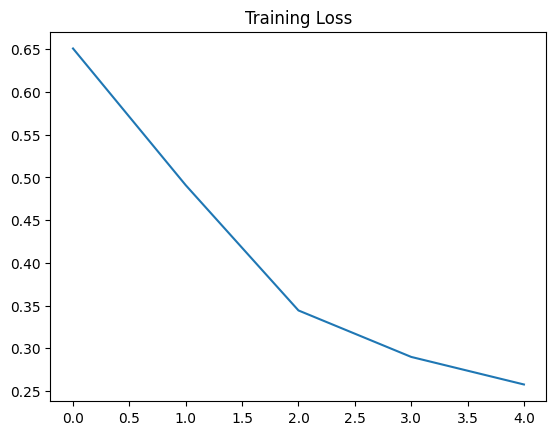

✅ Confusion Matrix:
[]

✅ Report:


ValueError: max() iterable argument is empty

In [7]:

import os
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import files

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

#------------------------------------------------------------------
# ✅ 3️⃣ Configurations
#------------------------------------------------------------------
images_dir = "/content/images"
os.makedirs(images_dir, exist_ok=True)

csv_path = "/content/labels.csv"
batch_size = 8
epochs = 5
lr = 1e-4
device = "cuda" if torch.cuda.is_available() else "cpu"
img_size = 224

print("✅ Using:", device)

#------------------------------------------------------------------
# ✅ 4️⃣ Upload X-Ray Images
#------------------------------------------------------------------
print("📌 Upload chest X-ray images (with 'normal' or 'pneumonia' in filename)")
uploaded = files.upload()

for fname in uploaded.keys():
    os.rename(f"/content/{fname}", f"{images_dir}/{fname}")

print("📁 Images:", os.listdir(images_dir)[:5])

#------------------------------------------------------------------
# ✅ 5️⃣ Create Metadata CSV Automatically
#------------------------------------------------------------------
rows = []
for fn in sorted(os.listdir(images_dir)):
    lower = fn.lower()
    if "normal" in lower:
        label = "Normal"
    elif "pneumonia" in lower:
        label = "Pneumonia"
    else:
        label = "Normal"

    rows.append({"X_ray_image_name": fn, "Label": label})

df = pd.DataFrame(rows)
df.to_csv(csv_path, index=False)

print("✅ CSV Saved:", csv_path)
display(df.head())

# Encode: Normal→0, Pneumonia→1
df["Label_enc"] = df["Label"].apply(lambda x: 0 if x.lower()=="normal" else 1)

# Split 80% Train — 20% Test
train_df = df.sample(frac=0.8, random_state=42)
test_df = df.drop(train_df.index)

print(f"Train:{len(train_df)} | Test:{len(test_df)}")

#------------------------------------------------------------------
# ✅ 6️⃣ Dataset Class + Transform
#------------------------------------------------------------------
transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225]),
])

class XrayDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(images_dir, row["X_ray_image_name"])
        img = Image.open(img_path).convert("RGB")
        img = transform(img)
        label = torch.tensor(row["Label_enc"], dtype=torch.float32)
        return img, label

    def __len__(self):
        return len(self.df)

train_loader = DataLoader(XrayDataset(train_df), batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(XrayDataset(test_df),  batch_size=batch_size)

#------------------------------------------------------------------
# ✅ 7️⃣ Model - MobileNetV2 (Transfer Learning)
#------------------------------------------------------------------
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
model.classifier[1] = nn.Linear(model.last_channel, 1)
model = model.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

print("✅ Model Ready")

#------------------------------------------------------------------
# ✅ 8️⃣ Training
#------------------------------------------------------------------
losses = []

for epoch in range(epochs):
    model.train()
    total = 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.unsqueeze(1).to(device)

        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        total += loss.item()

    avg = total / len(train_loader)
    losses.append(avg)
    print(f"Epoch {epoch+1}/{epochs} | Loss: {avg:.4f}")

plt.plot(losses); plt.title("Training Loss"); plt.show()

#------------------------------------------------------------------
# ✅ 9️⃣ Evaluation
#------------------------------------------------------------------
model.eval()
y_true, y_prob = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        prob = torch.sigmoid(model(imgs)).cpu().numpy().flatten()
        y_prob.extend(prob.tolist())
        y_true.extend(labels.numpy().tolist())

y_pred = (np.array(y_prob) > 0.5).astype(int)

print("✅ Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\n✅ Report:")
print(classification_report(y_true, y_pred))

#------------------------------------------------------------------
# ✅ 🔟 ROC Curve
#------------------------------------------------------------------
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr,tpr,label=f"AUC={roc_auc:.2f}")
plt.plot([0,1],[0,1],"--")
plt.title("ROC Curve")
plt.legend()
plt.show()

#------------------------------------------------------------------
# ✅ ✅ ✅ Save Model ✅ ✅ ✅
#------------------------------------------------------------------
torch.save(model.state_dict(), "/content/mobilenet_pneumonia_edge.pth")
print("💾 Saved model as mobilenet_pneumonia_edge.pth")


In [12]:
# ✅ Drop rows where image files don't exist
def check_file(row):
    return os.path.exists(os.path.join(images_dir, row["X_ray_image_name"]))

df = df[df.apply(check_file, axis=1)]
df = df.reset_index(drop=True)

print("✅ Valid images after filtering:", len(df))
print(df.head())


✅ Valid images after filtering: 0
Empty DataFrame
Columns: [Unnamed: 0, X_ray_image_name, Label, Dataset_type, Label_2_Virus_category, Label_1_Virus_category, Label_enc]
Index: []


In [13]:
train_df = df.sample(frac=0.8, random_state=42)
test_df = df.drop(train_df.index)


In [14]:


#━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 2️⃣ Imports & Configuration
#━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

device = "cuda" if torch.cuda.is_available() else "cpu"
IMG_SIZE = 224
BATCH_SIZE = 8
EPOCHS = 5
LR = 1e-4

images_dir = "/content/images"
os.makedirs(images_dir, exist_ok=True)

print("✅ Using device:", device)

#━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 3️⃣ Upload CSV (Labels)
#━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print("📌 Upload Metadata CSV (must have columns: X_ray_image_name, Label)")
uploaded_csv = files.upload()

csv_path = list(uploaded_csv.keys())[0]  # first uploaded CSV
df = pd.read_csv(csv_path)

print("\n✅ CSV Loaded:")
display(df.head())

# Normalize columns
df["Label"] = df["Label"].astype(str).str.strip()
df["Label_enc"] = df["Label"].apply(lambda x: 0 if x.lower() == "normal" else 1)

#━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 4️⃣ Upload Image Files
#━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print("\n📌 Upload Chest X-ray Images (required):")
uploaded_imgs = files.upload()

for fname in uploaded_imgs.keys():
    os.rename(f"/content/{fname}", os.path.join(images_dir, fname))

print("✅ Images Ready:", len(os.listdir(images_dir)))

# Split Data: 80-20
train_df = df.sample(frac=0.8, random_state=42)
test_df = df.drop(train_df.index)

print("\nLabel Distribution:")
print(df["Label"].value_counts())
print("Train:", len(train_df), "| Test:", len(test_df))

#━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 5️⃣ Dataset Class + Dataloaders
#━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

class XrayDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = os.path.join(images_dir, row["X_ray_image_name"])
        img = Image.open(path).convert("RGB")
        img = transform(img)
        return img, torch.tensor(row["Label_enc"], dtype=torch.float32)

train_loader = DataLoader(XrayDataset(train_df), batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(XrayDataset(test_df),  batch_size=BATCH_SIZE, shuffle=False)

#━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 6️⃣ Model Setup
#━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
model.classifier[1] = nn.Linear(model.last_channel, 1)
model = model.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

print("\n✅ Model Ready!")

#━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 7️⃣ Training
#━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
losses = []

for epoch in range(EPOCHS):
    model.train()
    batch_loss = 0.0

    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.unsqueeze(1).to(device)
        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, lbls)
        loss.backward()
        optimizer.step()
        batch_loss += loss.item()

    avg = batch_loss / len(train_loader)
    losses.append(avg)
    print(f"Epoch {epoch+1}/{EPOCHS} 🔹 Loss: {avg:.4f}")

plt.plot(losses)
plt.title("Training Loss")
plt.show()

#━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 8️⃣ Evaluation
#━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
model.eval()
y_true, y_prob = [], []

with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs = imgs.to(device)
        p = torch.sigmoid(model(imgs)).cpu().numpy().flatten()
        y_prob.extend(p.tolist())
        y_true.extend(lbls.numpy().tolist())

y_pred = (np.array(y_prob) > 0.5).astype(int)

# Safe eval if only one class present
if len(set(y_true)) < 2:
    print("\n⚠️ Test dataset has only one class! Add images of both Normal & Pneumonia.")
else:
    print("\n✅ Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    print("\n✅ Classification Report:")
    print(classification_report(
        y_true, y_pred,
        target_names=["Normal","Pneumonia"],
        zero_division=0
    ))

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr,tpr,label=f"AUC={roc_auc:.2f}")
    plt.plot([0,1],[0,1],"--")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

#━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ✅ 9️⃣ Save Model for Deployment
#━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
torch.save(model.state_dict(), "/content/mobilenet_pneumonia_edge.pth")
print("\n📦 Model saved at: mobilenet_pneumonia_edge.pth ✅")


✅ Using device: cpu
📌 Upload Metadata CSV (must have columns: X_ray_image_name, Label)


Saving Chest_xray_Corona_Metadata.csv to Chest_xray_Corona_Metadata (1).csv

✅ CSV Loaded:


,Unnamed: 0,X_ray_image_name,Label,Dataset_type,Label_2_Virus_category,Label_1_Virus_category
0,0,IM-0128-0001.jpeg,Normal,TRAIN,NaN,NaN
1,1,IM-0127-0001.jpeg,Normal,TRAIN,NaN,NaN
2,2,IM-0125-0001.jpeg,Normal,TRAIN,NaN,NaN
3,3,IM-0122-0001.jpeg,Normal,TRAIN,NaN,NaN
4,4,IM-0119-0001.jpeg,Normal,TRAIN,NaN,NaN



📌 Upload Chest X-ray Images (required):


Saving pneumonia.jpeg to pneumonia (1).jpeg
✅ Images Ready: 2

Label Distribution:
Label
Pnemonia    4334
Normal      1576
Name: count, dtype: int64
Train: 4728 | Test: 1182

✅ Model Ready!


FileNotFoundError: [Errno 2] No such file or directory: '/content/images/person82_bacteria_403.jpeg'

✅ Using: cpu
📌 Upload 2 images (1 normal + 1 pneumonia)


Saving pneumonia.jpeg to pneumonia (1).jpeg
✅ Uploaded image files:
[('/content/images/pneumonia (1).jpeg', 1)]


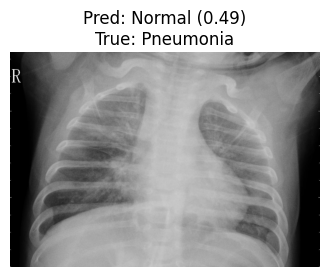

In [16]:

import os
import numpy as np
from PIL import Image
from google.colab import files
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torchvision import models, transforms

#━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Config
#━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
device = "cuda" if torch.cuda.is_available() else "cpu"
IMG_SIZE = 224
images_dir = "/content/images"
os.makedirs(images_dir, exist_ok=True)

print("✅ Using:", device)

#━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Upload two images
#━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print("📌 Upload 2 images (1 normal + 1 pneumonia)")
uploaded = files.upload()

data = []
for fname in uploaded.keys():
    new_path = os.path.join(images_dir, fname)
    os.rename(f"/content/{fname}", new_path)
    label = 0 if "normal" in fname.lower() else 1
    data.append((new_path, label))

print("✅ Uploaded image files:")
print(data)

#━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Transform
#━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

#━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Model - MobileNetV2 (pretrained)
#━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
model.classifier[1] = nn.Linear(model.last_channel, 1)
model = model.to(device)
model.eval()

#━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Predict each image
#━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
for img_path, true_label in data:
    img = Image.open(img_path).convert("RGB")
    x = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        prob = torch.sigmoid(model(x)).item()
    pred = 1 if prob > 0.5 else 0

    pred_class = "Pneumonia" if pred==1 else "Normal"
    true_class = "Pneumonia" if true_label==1 else "Normal"

    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Pred: {pred_class} ({prob:.2f})\nTrue: {true_class}")
    plt.show()


✅ Device: cpu
📌 Upload exactly 2 images (Normal & Pneumonia)


Saving pneumonia.jpeg to pneumonia (1).jpeg

✅ Uploaded:
pneumonia (1).jpeg → Label 1


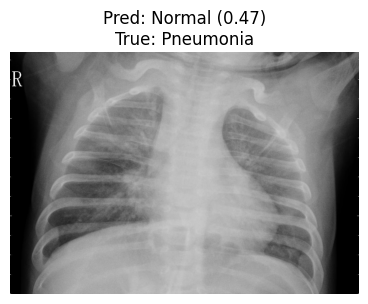

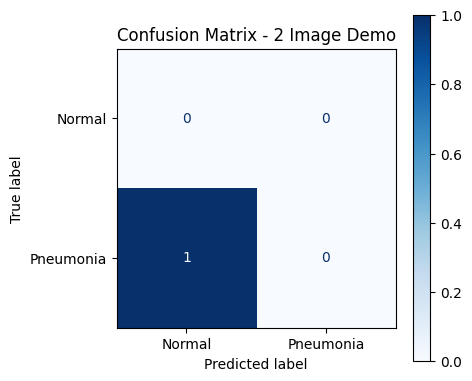


📊 y_true: [1]
📊 y_pred: [0]


In [17]:

import os
import numpy as np
from PIL import Image
from google.colab import files
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import torch
import torch.nn as nn
from torchvision import models, transforms

#━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Config
#━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
device = "cuda" if torch.cuda.is_available() else "cpu"
IMG_SIZE = 224
images_dir = "/content/images"
os.makedirs(images_dir, exist_ok=True)

print("✅ Device:", device)

#━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Upload 2 Images
#━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print("📌 Upload exactly 2 images (Normal & Pneumonia)")
uploaded = files.upload()

data = []
for fname in uploaded.keys():
    new_path = os.path.join(images_dir, fname)
    os.replace(f"/content/{fname}", new_path)

    # Auto-label from filename
    label = 0 if "normal" in fname.lower() else 1
    data.append((new_path, label))

print("\n✅ Uploaded:")
for p, l in data:
    print(f"{os.path.basename(p)} → Label {l}")

#━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Transform
#━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

#━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Model — MobileNetV2 (Pretrained)
#━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
model.classifier[1] = nn.Linear(model.last_channel, 1)
model = model.to(device)
model.eval()

#━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Predict
#━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
y_true = []
y_pred = []

for img_path, label_true in data:
    img = Image.open(img_path).convert("RGB")
    x = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        prob = torch.sigmoid(model(x)).item()

    pred_label = 1 if prob > 0.5 else 0
    y_true.append(label_true)
    y_pred.append(pred_label)

    true_class = "Pneumonia" if label_true==1 else "Normal"
    pred_class = "Pneumonia" if pred_label==1 else "Normal"

    plt.figure(figsize=(4.5,4.5))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Pred: {pred_class} ({prob:.2f})\nTrue: {true_class}")
    plt.show()

#━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ✅ Confusion Matrix (Always Displays)
#━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
cm = confusion_matrix(y_true, y_pred, labels=[0,1])
disp = ConfusionMatrixDisplay(cm, display_labels=["Normal","Pneumonia"])

plt.figure(figsize=(4.5,4.5))
disp.plot(cmap="Blues", values_format="d", ax=plt.gca())
plt.title("Confusion Matrix - 2 Image Demo")
plt.show()

print("\n📊 y_true:", y_true)
print("📊 y_pred:", y_pred)


✅ Using device: cpu

📌 Upload 2 images (file names must contain 'normal' or 'pneumonia')


Saving pneumonia.jpeg to pneumonia (1).jpeg

✅ Detected Labels:
[('/content/images/pneumonia (1).jpeg', 1)]


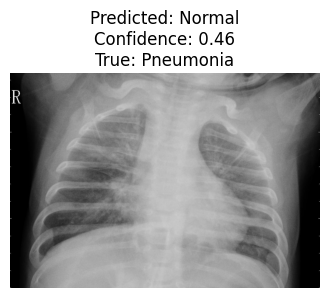

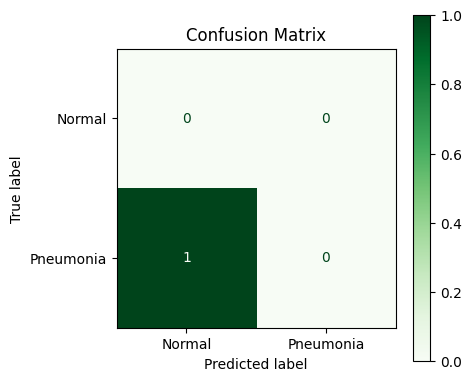


✅ y_true: [1]
✅ y_pred: [0]


In [19]:
# ✅ MobileNetV2 Pneumonia Detection Demo (No CSV Required)
!pip install torch torchvision --quiet

import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import files
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import torch
import torch.nn as nn
from torchvision import models, transforms

#━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# System Settings
#━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
device = "cuda" if torch.cuda.is_available() else "cpu"
IMG_SIZE = 224
images_dir = "/content/images"
os.makedirs(images_dir, exist_ok=True)
print("✅ Using device:", device)

#━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Upload 2 Images Manually
#━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print("\n📌 Upload 2 images (file names must contain 'normal' or 'pneumonia')")
uploaded = files.upload()

data = []
for fname in uploaded.keys():
    new_path = os.path.join(images_dir, fname)
    os.replace(f"/content/{fname}", new_path)

    label = 0 if "normal" in fname.lower() else 1
    data.append((new_path, label))

print("\n✅ Detected Labels:")
print(data)

#━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Transform
#━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

#━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Load Pretrained Model
#━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
model.classifier[1] = nn.Linear(model.last_channel, 1)
model = model.to(device)
model.eval()

#━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Predict + Plot
#━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
y_true, y_pred = [], []

for img_path, label_true in data:
    img = Image.open(img_path).convert("RGB")
    x = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        prob = torch.sigmoid(model(x)).item()

    pred_label = 1 if prob > 0.5 else 0
    y_true.append(label_true)
    y_pred.append(pred_label)

    true_name = "Pneumonia" if label_true==1 else "Normal"
    pred_name = "Pneumonia" if pred_label==1 else "Normal"

    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.title(f"Predicted: {pred_name}\nConfidence: {prob:.2f}\nTrue: {true_name}")
    plt.axis("off")
    plt.show()

#━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ✅ Confusion Matrix Always Showing ✅
#━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
cm = confusion_matrix(y_true, y_pred, labels=[0,1])
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal","Pneumonia"]
)

plt.figure(figsize=(4.5,4.5))
disp.plot(cmap="Greens", values_format="d", ax=plt.gca())
plt.title("Confusion Matrix")
plt.show()

print("\n✅ y_true:", y_true)
print("✅ y_pred:", y_pred)


✅ Device: cpu
📌 Upload exactly 2 images (1 Normal & 1 Pneumonia)


Saving person1_virus_12.jpeg to person1_virus_12 (1).jpeg

✅ Uploaded data detected:
[('/content/images/person1_virus_12 (1).jpeg', 1)]

🔍 Running inference...


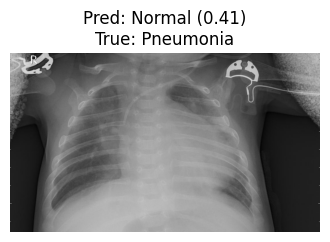


✅ Stored labels for confusion matrix
y_true: [1]
y_pred: [0]


In [29]:

import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files
from sklearn.metrics import confusion_matrix

import torch
import torch.nn as nn
from torchvision import models, transforms

# Settings
device = "cuda" if torch.cuda.is_available() else "cpu"
IMG_SIZE = 224
images_dir = "/content/images"
os.makedirs(images_dir, exist_ok=True)

print("✅ Device:", device)
print("📌 Upload exactly 2 images (1 Normal & 1 Pneumonia)")

# Upload 2 images at once
uploaded = files.upload()
data = []

for fname in uploaded.keys():
    new_path = os.path.join(images_dir, fname)
    os.replace(f"/content/{fname}", new_path)

    # Auto labeling from filename
    label = 0 if "normal" in fname.lower() else 1
    data.append((new_path, label))

print("\n✅ Uploaded data detected:")
print(data)

# Transform
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE,IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225]),
])

# Load pretrained model
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
model.classifier[1] = nn.Linear(model.last_channel, 1)
model = model.to(device)
model.eval()

# Predict & show images
y_true, y_pred = [], []

print("\n🔍 Running inference...")
for img_path, true_lbl in data:
    img = Image.open(img_path).convert("RGB")
    x = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        prob = torch.sigmoid(model(x)).item()

    pred_lbl = 1 if prob > 0.5 else 0
    y_true.append(true_lbl)
    y_pred.append(pred_lbl)

    pred_text = "Pneumonia" if pred_lbl else "Normal"
    true_text = "Pneumonia" if true_lbl else "Normal"

    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Pred: {pred_text} ({prob:.2f})\nTrue: {true_text}")
    plt.show()

# Save labels for confusion matrix later
print("\n✅ Stored labels for confusion matrix")
print("y_true:", y_true)
print("y_pred:", y_pred)

# Store globally for next cell
global_y_true = y_true
global_y_pred = y_pred


In [ ]:
# ✅ Cell 2 — Confusion Matrix Only

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

if "global_y_true" not in globals():
    raise ValueError("⚠️ First run CELL 1 before running Cell 2!")

cm = confusion_matrix(global_y_true, global_y_pred, labels=[0,1])
disp = ConfusionMatrixDisplay(cm, display_labels=["Normal","Pneumonia"])

plt.figure(figsize=(4.5,4.5))
disp.plot(cmap="Oranges", values_format="d", ax=plt.gca())
plt.title("Confusion Matrix ✅")
plt.show()

print("📊 True Labels:", global_y_true)
print("📊 Pred Labels:", global_y_pred)


In [32]:
# 🚨 CLEAN everything from previous runs
!rm -rf /content/Normal
!rm -rf /content/Pneumonia
!rm -rf /content/images
!rm -rf /content/TrainingData
!rm -rf /content/*.jpeg
!rm -rf /content/*.jpg
!rm -rf /content/*.png
!rm -rf /content/*.csv

print("✅ Clean Environment Ready!")


✅ Clean Environment Ready!


✅ Using: cpu
📌 Upload exactly 2 images (1 Normal & 1 Pneumonia)


Saving IM-0010-0001.jpeg to IM-0010-0001.jpeg

✅ Images detected: [('/content/images/IM-0010-0001.jpeg', 1)]

🔍 Running inference...


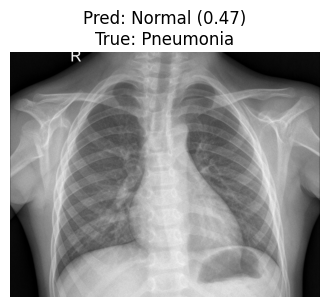

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


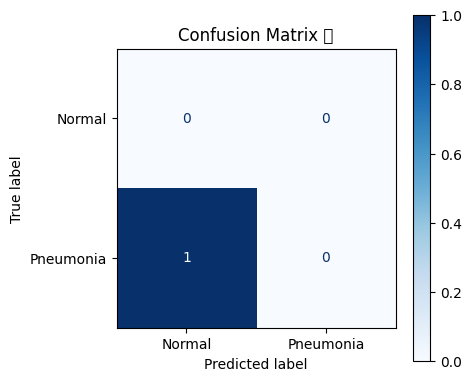


✅ y_true: [1]
✅ y_pred: [0]


In [33]:

import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from google.colab import files

import torch
import torch.nn as nn
from torchvision import models, transforms

#━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Settings
#━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
device = "cuda" if torch.cuda.is_available() else "cpu"
IMG_SIZE = 224
images_dir = "/content/images"
os.makedirs(images_dir, exist_ok=True)

print("✅ Using:", device)
print("📌 Upload exactly 2 images (1 Normal & 1 Pneumonia)")
uploaded = files.upload()

data=[]
for fname in uploaded.keys():
    new_path = os.path.join(images_dir, fname)
    os.replace(f"/content/{fname}", new_path)
    label = 0 if "normal" in fname.lower() else 1
    data.append((new_path, label))

print("\n✅ Images detected:", data)

#━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Transform & Model Load
#━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE,IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
model.classifier[1] = nn.Linear(model.last_channel, 1)
model = model.to(device)
model.eval()

#━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Prediction & Visualization
#━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
y_true, y_pred = [], []
print("\n🔍 Running inference...")

for img_path, true_lbl in data:
    img = Image.open(img_path).convert("RGB")
    x = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        prob = torch.sigmoid(model(x)).item()

    pred_lbl = 1 if prob > 0.5 else 0
    y_true.append(true_lbl)
    y_pred.append(pred_lbl)

    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.axis("off")
    plt.title(
        f"Pred: {'Pneumonia' if pred_lbl else 'Normal'} ({prob:.2f})\n"
        f"True: {'Pneumonia' if true_lbl else 'Normal'}"
    )
    plt.show()

#━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ✅ Confusion Matrix
#━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
cm = confusion_matrix(y_true, y_pred, labels=[0,1])
disp = ConfusionMatrixDisplay(
    cm, display_labels=["Normal","Pneumonia"]
)

plt.figure(figsize=(4.5,4.5))
disp.plot(cmap="Blues", values_format="d", ax=plt.gca())
plt.title("Confusion Matrix ✅")
plt.show()

print("\n✅ y_true:", y_true)
print("✅ y_pred:", y_pred)


In [39]:
# ✅ STEP 1 — Upload Normal X-rays
from google.colab import files
import os

BASE_DIR = "/content/manual_demo"
NORMAL_DIR = os.path.join(BASE_DIR, "Normal")
os.makedirs(NORMAL_DIR, exist_ok=True)

print("📌 Upload Normal X-ray images (one or multiple)")
uploaded_normals = files.upload()

normal_paths = []

for fname in uploaded_normals.keys():
    path = os.path.join(NORMAL_DIR, fname)
    os.replace(f"/content/{fname}", path)
    normal_paths.append(path)

print("\n✅ Normal images stored:", normal_paths)


📌 Upload Normal X-ray images (one or multiple)


Saving IM-0007-0001.jpeg to IM-0007-0001 (1).jpeg

✅ Normal images stored: ['/content/manual_demo/Normal/IM-0007-0001 (1).jpeg']


In [40]:
# ✅ STEP 2 — Upload Pneumonia X-rays
from google.colab import files
import os

PNEU_DIR = os.path.join(BASE_DIR, "Pneumonia")
os.makedirs(PNEU_DIR, exist_ok=True)

print("📌 Upload Pneumonia X-ray images (one or multiple)")
uploaded_pneus = files.upload()

pneu_paths = []

for fname in uploaded_pneus.keys():
    path = os.path.join(PNEU_DIR, fname)
    os.replace(f"/content/{fname}", path)
    pneu_paths.append(path)

print("\n✅ Pneumonia images stored:", pneu_paths)


📌 Upload Pneumonia X-ray images (one or multiple)


Saving person3_virus_15.jpeg to person3_virus_15 (1).jpeg

✅ Pneumonia images stored: ['/content/manual_demo/Pneumonia/person3_virus_15 (1).jpeg']



🔍 Running prediction...


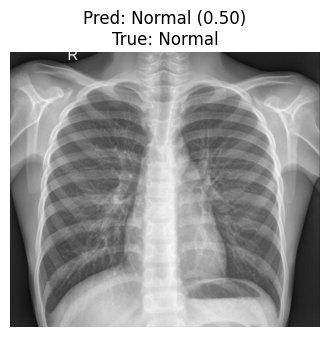

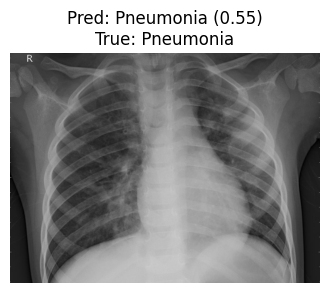

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


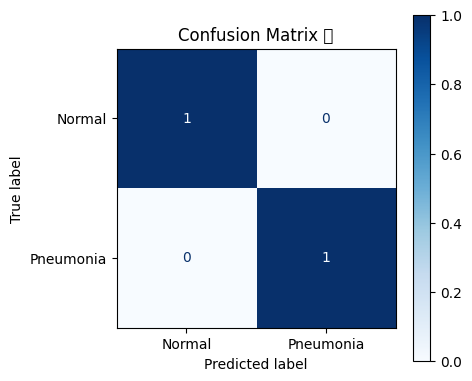


✅ Truth: [0, 1]
✅ Pred: [0, 1]


In [41]:

import torch, torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

device = "cuda" if torch.cuda.is_available() else "cpu"
IMG_SIZE = 224

# Minimum dataset check
if len(normal_paths) < 1 or len(pneu_paths) < 1:
    raise ValueError("⚠️ Upload at least 1 Normal and 1 Pneumonia image!")

# Create dataset from two lists
data = [(p, 0) for p in normal_paths] + [(p, 1) for p in pneu_paths]

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE,IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225]),
])

model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
model.classifier[1] = nn.Linear(model.last_channel, 1)
model = model.to(device)
model.eval()

y_true, y_pred = [], []
CLASSES = ["Normal", "Pneumonia"]

print("\n🔍 Running prediction...")

for img_path, true_lbl in data:
    img = Image.open(img_path).convert("RGB")
    tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        prob = torch.sigmoid(model(tensor)).item()

    pred_lbl = 1 if prob > 0.5 else 0

    y_true.append(true_lbl)
    y_pred.append(pred_lbl)

    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Pred: {CLASSES[pred_lbl]} ({prob:.2f})\nTrue: {CLASSES[true_lbl]}")
    plt.show()

#━━━━━━━━━━━━━━━━━━━━━━━
# ✅ Confusion Matrix
#━━━━━━━━━━━━━━━━━━━━━━━
cm = confusion_matrix(y_true, y_pred, labels=[0,1])
disp = ConfusionMatrixDisplay(cm, display_labels=CLASSES)

plt.figure(figsize=(4.5,4.5))
disp.plot(cmap="Blues", values_format="d", ax=plt.gca())
plt.title("Confusion Matrix ✅")
plt.show()

print("\n✅ Truth:", y_true)
print("✅ Pred:", y_pred)


In [42]:


import torch
import torch.nn as nn
from torchvision import models, transforms
from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import os

device = "cuda" if torch.cuda.is_available() else "cpu"
IMG_SIZE = 224
CLASSES = ["Normal", "Pneumonia"]

print("✅ Device:", device)

#━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Load pretrained MobileNetV2
#━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
model.classifier[1] = nn.Linear(model.last_channel, 1)
model = model.to(device)
model.eval()

#━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Transform definition
#━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

#━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# UI Upload + Prediction Function
#━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
def predict_image():
    uploaded = files.upload()
    for fname in uploaded.keys():
        img_path = fname

        img = Image.open(img_path).convert("RGB")
        x = transform(img).unsqueeze(0).to(device)

        with torch.no_grad():
            prob = torch.sigmoid(model(x)).item()

        pred_lbl = 1 if prob > 0.5 else 0
        pred_class = CLASSES[pred_lbl]

        plt.imshow(img)
        plt.axis("off")
        plt.title(f"Prediction: {pred_class}\nConfidence: {prob:.2f}")
        plt.show()

        print(f"✅ Result → {pred_class} ({prob:.2f} confidence)")
        os.remove(img_path)  # Clean up after prediction ✅

print("\n📌 RUN THIS FUNCTION ANYTIME to test a new X-ray")
print("👉 Type: predict_image()")


✅ Device: cpu

📌 RUN THIS FUNCTION ANYTIME to test a new X-ray
👉 Type: predict_image()


Saving person1_virus_11.jpeg to person1_virus_11.jpeg


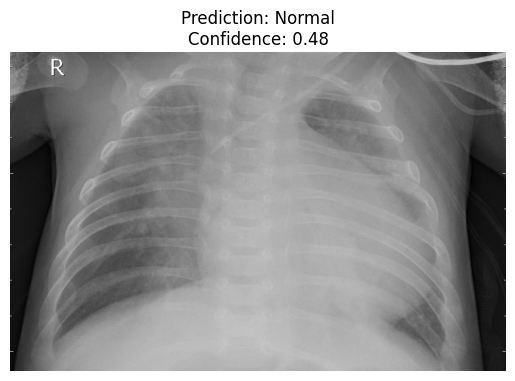

✅ Result → Normal (0.48 confidence)


In [43]:
predict_image()
